# Week 3: 스타듀밸리 위키 RAG 시스템

## 구성
- **도메인**: 스타듀밸리 한국어 위키 (마크다운)
- **벡터스토어**: FAISS (베이스라인) + PGVector (persist)
- **청킹 전략**: MarkdownHeaderTextSplitter (chunking_compare.ipynb 비교 결과 기준)
- **그래프**: LangGraph v1 (TypedDict + Annotated), 2-step RAG (retrieve → generate)
- **출처 출력**: 답변에 근거 문서/카테고리 함께 출력

![Naive RAG](../../../week3-rag-basics/assets/langgraph-naive-rag.png)

## 0. 환경 설정

In [15]:
import sys
sys.path.insert(0, '..')

from dotenv import load_dotenv
load_dotenv(dotenv_path='../.env', override=True)
# week3 로컬 .env도 병합 (POSTGRES_URI 등)
load_dotenv(dotenv_path='.env', override=False)

import os
from pathlib import Path

DOCS_DIR = Path('data/docs_sample')
print(f'문서 수: {len(list(DOCS_DIR.glob("*.md")))}')

문서 수: 24


## 1. 인덱싱: loader → splitter → embedding → FAISS

In [16]:
from rag.wiki import WikiRetrievalChain

# chunking_compare.ipynb 결과를 보고 전략 선택 (기본: markdown_header)
SPLITTER_TYPE = 'markdown_header'  # 또는 'recursive'

wiki_chain = WikiRetrievalChain(
    source_uri=str(DOCS_DIR),
    splitter_type=SPLITTER_TYPE,
).create_chain()

retriever = wiki_chain.retriever
chain = wiki_chain.chain

print(f'Retriever: {retriever}')
print(f'Vectorstore: {wiki_chain.vectorstore}')

Loaded: crafting_overview.md (제작)
Loaded: farming_ancient_seed.md (농사)
Loaded: farming_crops.md (농사)
Loaded: farming_crops_fall.md (농사)
Loaded: farming_crops_spring.md (농사)
Loaded: farming_crops_summer.md (농사)
Loaded: farming_crops_winter.md (농사)
Loaded: farming_greenhouse.md (농사)
Loaded: farming_keg.md (농사)
Loaded: farming_lightning_rod.md (농사)
Loaded: farming_preserves_jar.md (농사)
Loaded: fishing_fish_list.md (낚시)
Loaded: fishing_overview.md (낚시)
Loaded: fishing_tackle.md (낚시)
Loaded: foraging_overview.md (채집)
Loaded: livestock_animals.md (축산)
Loaded: livestock_barn.md (축산)
Loaded: livestock_coop.md (축산)
Loaded: livestock_mayonnaise.md (축산)
Loaded: mining_dwarf_scroll1.md (광산)
Loaded: mining_dwarf_scroll2.md (광산)
Loaded: mining_overview.md (광산)
Loaded: villagers_hearts.md (주민)
Loaded: villagers_marriage.md (주민)

Loaded 24 documents, 0 failed.
Split into 339 chunks (markdown_header)
FAISS index saved to cache
Retriever: tags=['FAISS', 'OpenAIEmbeddings'] vectorstore=<langchain_communi

## 2. 검색 테스트

In [17]:
from rag.utils import format_docs

test_query = '양조통에 넣을 수 있는 재료는?'
retrieved = retriever.invoke(test_query)

print(f'Query: {test_query}')
print(f'검색된 청크 수: {len(retrieved)}')
for i, doc in enumerate(retrieved, 1):
    print(f'\n#{i} [{doc.metadata.get("category","")}] {Path(doc.metadata.get("source","")).name}')
    print(doc.page_content[:300])

Query: 양조통에 넣을 수 있는 재료는?
검색된 청크 수: 6

#1 [농사] farming_preserves_jar.md
# Farming Preserves Jar  
|  |  |
| --- | --- |
| 절임통 | |
| [Preserves Jar.png](/%ED%8C%8C%EC%9D%BC:Preserves_Jar.png) | |
| 채소를 넣어두면 피클을 만들고, 과일을 넣어두면 잼을 만듭니다. | |
| 정보 | |
| 입수처 | [제작](/%EC%A0%9C%EC%9E%91 "제작") |
| 판매가격 | *판매 불가* |
| 제작 | |
| 제작법 입수처 | Farming Skill Icon.png [농사](/%EB%86%8D%EC%82%

#2 [농사] farming_crops.md
## 장인 제작품  
판매 가치를 올리기 위해 작물을 [장인 제작품](/%EC%9E%A5%EC%9D%B8_%EC%A0%9C%EC%9E%91%ED%92%88 "장인 제작품")으로 만들 수 있습니다. 대부분의 [과일](/%EA%B3%BC%EC%9D%BC "과일")과 [야채](/%EC%95%BC%EC%B1%84 "야채")는 [절임통](/%EC%A0%88%EC%9E%84%ED%86%B5 "절임통")을 통해 [젤리와 피클](/%EC%A0%A4%EB%A6%AC%EC%99%80_%ED%94%BC%ED%81%B4 "젤리와 피클")을 만들거나 [술

#3 [축산] livestock_animals.md
### 양  
:   주요 문서: [양](/%EC%96%91 "양")  
| 사진 | 이름 | 비용 | 필요한 것 | 생산품 | 5 하트 때 판매가 |
| --- | --- | --- | --- | --- | --- |
| [Sheep.png](/%ED%8C%8C%EC%9D%BC:Sheep.png) | [양](/%EC%96%91 "양") | data-sort-value="8000">Gold.png8,000골드 | 디럭스 외양간 | [Wool.png](/%ED%8C%8C%EC%9D%

## 3. GraphState 및 노드 정의 (LangGraph v1)

In [18]:
from typing import Annotated, TypedDict, List
from langgraph.graph.message import add_messages
from langchain_core.documents import Document


class GraphState(TypedDict):
    question: Annotated[str, 'Question']          # 사용자 질문
    context: Annotated[str, 'Context']            # 포맷된 검색 문서 문자열
    answer: Annotated[str, 'Answer']              # 생성된 답변
    source_docs: Annotated[List[Document], 'Source documents']  # 원본 문서 (출처 출력용)
    messages: Annotated[list, add_messages]       # 대화 히스토리

In [19]:
from rag.utils import format_docs, format_source_list


def retrieve_document(state: GraphState) -> GraphState:
    """질문으로 위키 문서 검색 후 포맷."""
    question = state['question']
    docs = retriever.invoke(question)
    context = format_docs(docs)
    return {'context': context, 'source_docs': docs}


def llm_answer(state: GraphState) -> GraphState:
    """검색된 컨텍스트 + 질문으로 LLM 답변 생성. 출처 목록을 답변 하단에 부착."""
    question = state['question']
    context = state['context']
    source_docs = state.get('source_docs', [])

    llm_response = chain.invoke({'question': question, 'context': context})

    # 출처 목록 부착
    source_str = format_source_list(source_docs)
    full_answer = f'{llm_response}\n\n**출처**\n{source_str}'

    return {
        'answer': full_answer,
        'messages': [('user', question), ('assistant', full_answer)],
    }

## 4. 그래프 구성 및 컴파일

In [20]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(GraphState)

workflow.add_node('retrieve', retrieve_document)
workflow.add_node('llm_answer', llm_answer)

workflow.add_edge(START, 'retrieve')
workflow.add_edge('retrieve', 'llm_answer')
workflow.add_edge('llm_answer', END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print('Graph compiled successfully')

Graph compiled successfully


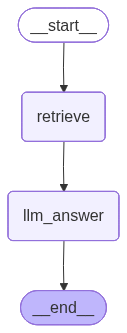

In [21]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

## 5. 실행 헬퍼

In [22]:
import uuid
from langchain_core.runnables import RunnableConfig


def ask(question: str, thread_id: str | None = None) -> str:
    """단일 질문을 RAG 그래프에 던지고 답변 반환."""
    tid = thread_id or str(uuid.uuid4())
    config = RunnableConfig(
        recursion_limit=10,
        configurable={'thread_id': tid},
    )
    state = GraphState(question=question, context='', answer='', source_docs=[], messages=[])
    result = app.invoke(state, config)
    return result['answer']


def ask_print(question: str):
    print(f'\n{'='*60}')
    print(f'Q: {question}')
    print('='*60)
    answer = ask(question)
    print(answer)

## 6. 최종 테스트 질문 5개+ 실행

In [23]:
import sys
sys.path.insert(0, '.')
from eval.test_questions import FINAL_TEST_QUESTIONS

for q in FINAL_TEST_QUESTIONS:
    ask_print(q)


Q: 양조통(술통)에 넣을 수 있는 재료와 각각 만들어지는 제품은?


TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

## 7. Group B 질문 관찰 (RAG 실패 케이스)

In [10]:
from eval.test_questions import GROUP_B_QUESTIONS

for item in GROUP_B_QUESTIONS[:3]:  # 3개만
    ask_print(item['question'])
    print(f'[관찰 포인트] {item["reason"][:80]}...')


Q: 농작물 상자에 넣는 것과 피에르에게 파는 것의 차이가 있나?


TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

## 8. PGVector persist 버전

`POSTGRES_URI`가 `.env`에 설정되어 있어야 합니다.  
week2에서 사용한 PostgreSQL 인스턴스 재활용 (`stardew_agent` DB).

In [11]:
import os
POSTGRES_URI = os.getenv('POSTGRES_URI')

if not POSTGRES_URI:
    print('POSTGRES_URI 미설정. PGVector 셀 스킵.')
else:
    from langchain_postgres import PGVector
    from langchain_openai import OpenAIEmbeddings
    from rag.wiki import WikiRetrievalChain

    # 문서 로드 + 분할
    _loader = WikiRetrievalChain(source_uri=str(DOCS_DIR), splitter_type=SPLITTER_TYPE)
    _raw_docs = _loader.load_documents(str(DOCS_DIR))
    _splitter = _loader.create_text_splitter()
    _split_docs = _loader.split_documents(_raw_docs, _splitter)

    embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
    COLLECTION_NAME = 'stardew_wiki'

    pg_vectorstore = PGVector(
        embeddings=embeddings,
        collection_name=COLLECTION_NAME,
        connection=POSTGRES_URI,
        use_jsonb=True,
    )

    # 기존 컬렉션 삭제 후 새로 추가 (재실행 대비)
    pg_vectorstore.drop_tables()
    pg_vectorstore = PGVector.from_documents(
        documents=_split_docs,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        connection=POSTGRES_URI,
        use_jsonb=True,
    )

    pg_retriever = pg_vectorstore.as_retriever(search_kwargs={'k': 6})
    print(f'PGVector 인덱싱 완료: {len(_split_docs)}개 청크')

Loaded: crafting_overview.md (제작)
Loaded: farming_ancient_seed.md (농사)
Loaded: farming_crops.md (농사)
Loaded: farming_crops_fall.md (농사)
Loaded: farming_crops_spring.md (농사)
Loaded: farming_crops_summer.md (농사)
Loaded: farming_crops_winter.md (농사)
Loaded: farming_greenhouse.md (농사)
Loaded: farming_keg.md (농사)
Loaded: farming_lightning_rod.md (농사)
Loaded: farming_preserves_jar.md (농사)
Loaded: fishing_fish_list.md (낚시)
Loaded: fishing_overview.md (낚시)
Loaded: fishing_tackle.md (낚시)
Loaded: foraging_overview.md (채집)
Loaded: livestock_animals.md (축산)
Loaded: livestock_barn.md (축산)
Loaded: livestock_coop.md (축산)
Loaded: livestock_mayonnaise.md (축산)
Loaded: mining_dwarf_scroll1.md (광산)
Loaded: mining_dwarf_scroll2.md (광산)
Loaded: mining_overview.md (광산)
Loaded: villagers_hearts.md (주민)
Loaded: villagers_marriage.md (주민)

Loaded 24 documents, 0 failed.
Split into 339 chunks (markdown_header)


ModuleNotFoundError: No module named 'psycopg2'

In [12]:
if POSTGRES_URI:
    # PGVector retriever로 같은 질문 테스트
    test_q = '양조통에 넣을 수 있는 재료와 산출 제품은?'
    pg_docs = pg_retriever.invoke(test_q)
    print(f'PGVector 검색 결과 ({len(pg_docs)}개):')
    for i, d in enumerate(pg_docs, 1):
        print(f'  #{i} [{d.metadata.get("category","")}] {d.page_content[:150]}')

NameError: name 'pg_retriever' is not defined

## 9. FAISS vs PGVector 트레이드오프

| | FAISS (인메모리) | PGVector (persist) |
|--|--|--|
| 속도 | 빠름 | 상대적으로 느림 (네트워크 I/O) |
| 영속성 | 재시작 시 재색인 필요 (캐시 파일 있으면 복원) | DB에 영구 저장 |
| 메타데이터 필터링 | 제한적 (FAISS filter 파라미터) | SQL 쿼리 수준 필터링 |
| 스케일 | 소규모 문서에 적합 | 대규모 확장 용이 |
| 인프라 | 별도 서버 불필요 | PostgreSQL 서버 필요 |